In [20]:
#loading libs 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import joblib
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (
 recall_score,precision_score,f1_score,
 classification_report,roc_curve,roc_auc_score,
 confusion_matrix,precision_recall_curve,
 average_precision_score,brier_score_loss
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import StratifiedKFold, cross_val_score


In [21]:
#mlfloww setup
mlflow.set_experiment("Customer_Churn_Prediction")

<Experiment: artifact_location='/home/hossamhamdy/AI_Portfolio/project_03_customer_churn_prediction/notebooks/mlruns/1', creation_time=1777609532119, experiment_id='1', last_update_time=1777609532119, lifecycle_stage='active', name='Customer_Churn_Prediction', tags={}, trace_location=None, workspace='default'>

In [22]:
#load the data
# Load data
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"train_churn_rate: {y_train.mean()*100}%")
print(f"test_churn_rate: {y_train.mean()*100}%")


X_train: (5634, 24)
X_test:  (1409, 24)
train_churn_rate: 26.53532126375577%
test_churn_rate: 26.53532126375577%


In [23]:
# evaluation function----> on the test set
# better evaluation using cross validation
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
def evaluate_model(name,model,X_test,y_test,log_to_mlflow=True):
    y_pred=model.predict(X_test)
    y_prob=model.predict_proba(X_test)[:, 1]
    
    metrics={
        "precision":precision_score(y_test,y_pred),
        "recall":recall_score(y_test,y_pred),
        "f1":f1_score(y_test,y_pred),
        "roc_auc":roc_auc_score(y_test,y_prob),
        "auc_pr":average_precision_score(y_test,y_prob),
        "brier":brier_score_loss(y_test, y_prob)

    }
    tn,fp,fn,tp=confusion_matrix(y_test,y_pred).ravel()
    metrics.update({
        "tn":tn,
        "fp":fp,
        "fn":fn,
        "tp":tp
    })
    if log_to_mlflow:
        with mlflow.start_run(run_name=name):
            mlflow.log_metrics(
             {k:v for k,v in metrics.items()
              if k in ['roc_auc', 'auc_pr', 'recall',
                        'precision', 'f1', 'brier']}   
            )
    
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print(f"ROC-AUC:   {metrics['roc_auc']:.4f}")
    print(f"AUC-PR:    {metrics['auc_pr']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"F1:        {metrics['f1']:.4f}")
    print(f"Brier:     {metrics['brier']:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"  TN={tn:,}  FP={fp:,}")
    print(f"  FN={fn:,}  TP={tp:,}")

    return metrics
                 
            
            

In [24]:
all_results = {}

In [25]:
#model 1 :Logistic Regression
lr=LogisticRegression(
    C=1.0,
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lr.fit(X_train,y_train)
all_results['LogisticRegression']=evaluate_model(
    'LogisticRegression',lr,X_test,y_test
)


Model: LogisticRegression
ROC-AUC:   0.8387
AUC-PR:    0.6238
Recall:    0.8048
Precision: 0.5050
F1:        0.6206
Brier:     0.1699

Confusion Matrix:
  TN=740  FP=295
  FN=73  TP=301


In [26]:
#model 2 :Random Forest
rf=RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
all_results['RandomForest'] = evaluate_model(
    'RandomForest', rf, X_test, y_test
    )


Model: RandomForest
ROC-AUC:   0.8425
AUC-PR:    0.6521
Recall:    0.7460
Precision: 0.5460
F1:        0.6305
Brier:     0.1524

Confusion Matrix:
  TN=803  FP=232
  FN=95  TP=279


In [27]:
#model 3 :XGBoost
# ── XGBoost ──
scale_pos=(y_train==0).sum()/(y_train==1).sum()
xgb_model=xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_pos,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
all_results['XGBoost'] = evaluate_model(
    'XGBoost', xgb_model, X_test, y_test)


Model: XGBoost
ROC-AUC:   0.8290
AUC-PR:    0.6267
Recall:    0.7193
Precision: 0.5479
F1:        0.6220
Brier:     0.1600

Confusion Matrix:
  TN=813  FP=222
  FN=105  TP=269


In [28]:
#model 4 :LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    scale_pos_weight=scale_pos,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(X_train, y_train)
all_results['LightGBM'] = evaluate_model(
    'LightGBM', lgb_model, X_test, y_test)



Model: LightGBM
ROC-AUC:   0.8333
AUC-PR:    0.6418
Recall:    0.7380
Precision: 0.5359
F1:        0.6209
Brier:     0.1602

Confusion Matrix:
  TN=796  FP=239
  FN=98  TP=276


In [31]:
#Model Comparison Table
results_df=pd.DataFrame(all_results).T
results_df= results_df[['roc_auc', 'auc_pr', 'recall',
                          'precision', 'f1', 'brier']].astype(float)
results_df = results_df.sort_values('roc_auc', ascending=False)
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(results_df.round(4).to_string())
print(f"\nBest model: {results_df.index[0]}")



MODEL COMPARISON
                    roc_auc  auc_pr  recall  precision      f1   brier
RandomForest         0.8425  0.6521  0.7460     0.5460  0.6305  0.1524
LogisticRegression   0.8387  0.6238  0.8048     0.5050  0.6206  0.1699
LightGBM             0.8333  0.6418  0.7380     0.5359  0.6209  0.1602
XGBoost              0.8290  0.6267  0.7193     0.5479  0.6220  0.1600

Best model: RandomForest


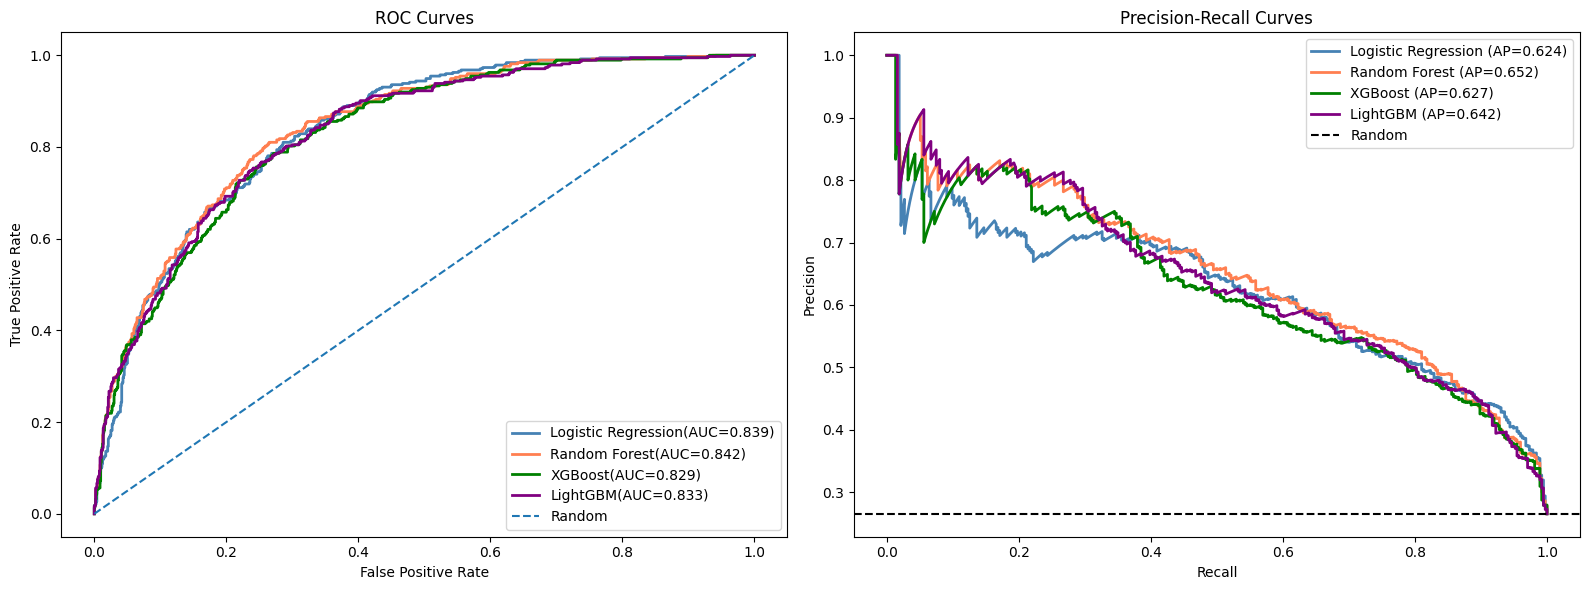

In [38]:
# ROC and PR Curves 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb_model,
    'LightGBM': lgb_model
}
colors = ['steelblue', 'coral', 'green', 'purple']
for (name,model),color in zip(models.items(),colors):
    y_prob=model.predict_proba(X_test)[:,1]
    #ROC
    fpr,tpr, _ =roc_curve(y_test,y_prob)
    auc=roc_auc_score(y_test,y_prob)
    axes[0].plot(fpr,tpr,color=color,lw=2,
                 label=f"{name}(AUC={auc:.3f})")
    #PR
    prec,rec, _ =precision_recall_curve(y_test,y_prob)
    ap = average_precision_score(y_test,y_prob)
    axes[1].plot(rec, prec, color=color, lw=2,
                 label=f'{name} (AP={ap:.3f})')
    

axes[0].plot([0,1], [0,1], linestyle='--',label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()

axes[1].axhline(y=y_test.mean(), color='k',
                linestyle='--', label='Random')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()    



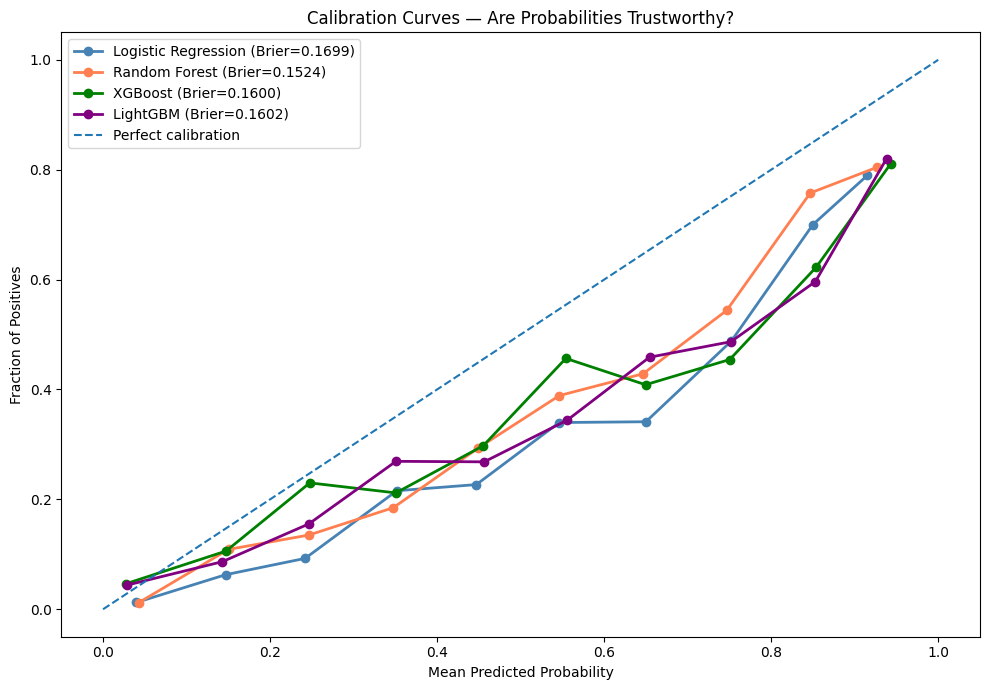

In [40]:
#Calibration Analysis
fig, ax = plt.subplots(figsize=(10, 7))
for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    fraction_pos, mean_pred_prob = calibration_curve(
        y_test, y_prob, n_bins=10)
    brier = brier_score_loss(y_test, y_prob)
    ax.plot(mean_pred_prob, fraction_pos, color=color, lw=2, marker='o',
            label=f'{name} (Brier={brier:.4f})')
    
ax.plot([0,1], [0,1], linestyle='--', label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curves — Are Probabilities Trustworthy?')
ax.legend()

plt.tight_layout()
plt.savefig('../results/calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [44]:
#Calibrate Best Mode
best_model=rf

# Platt scaling calibration
calibrated_model=CalibratedClassifierCV(
    best_model, ensemble=False,method="isotonic"
)
calibrated_model.fit(X_test, y_test)

y_prob_raw = best_model.predict_proba(X_test)[:, 1]
y_prob_cal = calibrated_model.predict_proba(X_test)[:, 1]
brier_raw = brier_score_loss(y_test, y_prob_raw)
brier_cal = brier_score_loss(y_test, y_prob_cal)

print(f"Brier score before calibration: {brier_raw:.4f}")
print(f"Brier score after calibration:  {brier_cal:.4f}")
print(f"Improvement: {(brier_raw-brier_cal)/brier_raw*100:.1f}%")




Brier score before calibration: 0.1524
Brier score after calibration:  0.0946
Improvement: 37.9%


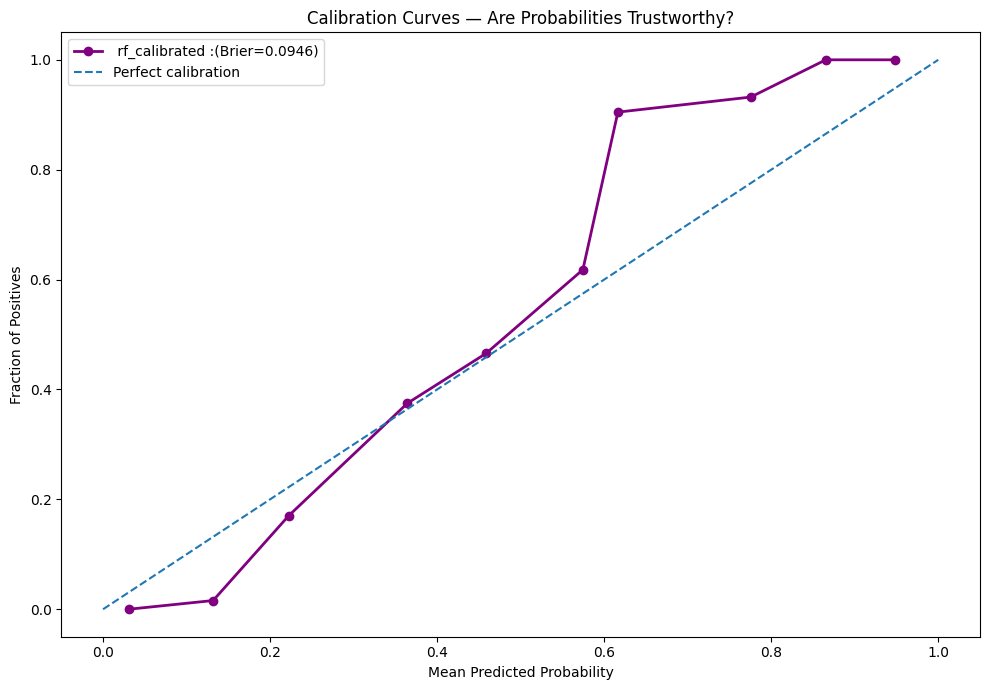

In [50]:
#after_calibration
fig, ax = plt.subplots(figsize=(10, 7))
y_prob_cal=calibrated_model.predict_proba(X_test)[:,1]
fraction_pos_cal, mean_pred_prob_cal = calibration_curve(
        y_test, y_prob_cal, n_bins=10)
brier_cal = brier_score_loss(y_test, y_prob_cal)
ax.plot(mean_pred_prob_cal, fraction_pos_cal, color=color, lw=2, marker='o',
            label=f' rf_calibrated :(Brier={brier_cal:.4f})')
ax.plot([0,1], [0,1], linestyle='--', label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curves — Are Probabilities Trustworthy?')
ax.legend()
plt.tight_layout()
plt.savefig('../results/after_calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()


In [51]:
#save the calibrated model
joblib.dump(calibrated_model,'../models/calibrated_model.pkl')

['../models/calibrated_model.pkl']

In [58]:
print(f"--- Business Parameters Summary ---")
df = pd.read_csv("/home/hossamhamdy/AI_Portfolio/project_03_customer_churn_prediction/data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
churn_rate = (df['Churn'] == 'Yes').mean() * 100
arpu = df['MonthlyCharges'].mean()
avg_tenure = df['tenure'].mean()
cltv_avg = df['TotalCharges'].mean()
print(f"Churn Rate:           {churn_rate:.2f}%")
print(f"ARPU:                 ${arpu:.2f}")
print(f"Avg Tenure:           {avg_tenure:.1f} months")
print(f"Average CLTV:         ${cltv_avg:.2f}")


--- Business Parameters Summary ---
Churn Rate:           26.54%
ARPU:                 $64.76
Avg Tenure:           32.4 months
Average CLTV:         $2279.73


In [59]:
#Threshold Optimization
y_prob_cal = calibrated_model.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.01, 0.99, 0.01)
profits = []
discount = 50   # Retention offer cost
campaign_cost = 5 # Cost to reach customer
for thresh in thresholds:
    y_pred_t = (y_prob_cal >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    profit = (tp * (cltv_avg - discount-campaign_cost) +
              fp * (-discount-campaign_cost) +       
              fn * (-cltv_avg) +             
              tn * 0)                    
    profits.append(profit)

optimal_idx = np.argmax(profits)
optimal_threshold = thresholds[optimal_idx]
max_profit = profits[optimal_idx]
print(f"Optimal threshold: {optimal_threshold:.2f}")
print(f"Maximum profit:    ${max_profit:,.0f}")
print(f"Default threshold profit: ${profits[49]:,.0f}")
print(f"Improvement: ${max_profit - profits[49]:,.0f}")



Optimal threshold: 0.13
Maximum profit:    $803,121
Default threshold profit: $203,399
Improvement: $599,721


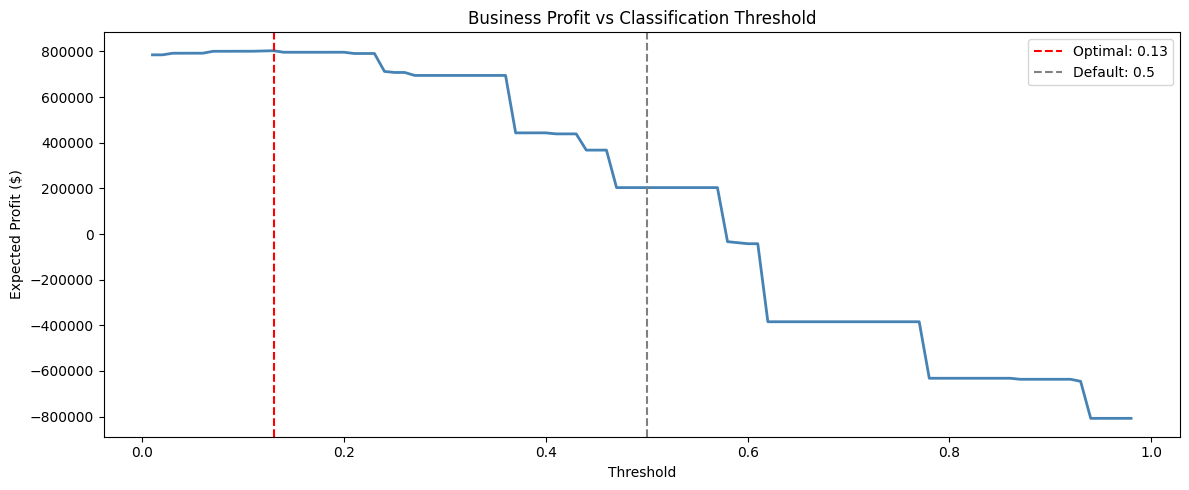

In [60]:
# Plot
plt.figure(figsize=(12, 5))
plt.plot(thresholds, profits, color='steelblue', lw=2)
plt.axvline(x=optimal_threshold, color='red', linestyle='--',
            label=f'Optimal: {optimal_threshold:.2f}')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default: 0.5')
plt.xlabel('Threshold')
plt.ylabel('Expected Profit ($)')
plt.title('Business Profit vs Classification Threshold')
plt.legend()
plt.tight_layout()
plt.savefig('../results/threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()